## Hafta 3 — Makine Öğrenmesi Temelleri

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql://postgres@localhost:5432/fintech_db"
)

df = pd.read_sql("SELECT * FROM islemler", engine)
df.head()

,islem_id,musteri_id,tutar,kategori,durum
0,1,1,1500.0,Alışveriş,onaylı
1,2,2,320.0,Fatura,onaylı
2,3,3,8900.0,Transfer,beklemede
3,4,1,450.0,Fatura,onaylı
4,5,4,12000.0,Transfer,iptal


In [2]:
# Metinleri sayıya çevir
le = LabelEncoder()
df['kategori_enc'] = le.fit_transform(df['kategori'])
df['durum_enc']    = le.fit_transform(df['durum'])

print(df[['kategori', 'kategori_enc', 'durum', 'durum_enc']])

    kategori  kategori_enc      durum  durum_enc
0  Alışveriş             0     onaylı          2
1     Fatura             1     onaylı          2
2   Transfer             2  beklemede          0
3     Fatura             1     onaylı          2
4   Transfer             2      iptal          1
5  Alışveriş             0     onaylı          2
6  Alışveriş             0     onaylı          2
7     Fatura             1     onaylı          2
8   Transfer             2     onaylı          2
9  Alışveriş             0  beklemede          0


In [3]:
# Girdi ve çıktı
X = df[['tutar', 'kategori_enc', 'musteri_id']]
y = df['durum_enc']

# Böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print("Eğitim seti:", len(X_train), "satır")
print("Test seti:  ", len(X_test), "satır")

Eğitim seti: 8 satır
Test seti:   2 satır


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Modeli kur
model = RandomForestClassifier(random_state=42)

# Eğit
model.fit(X_train, y_train)

# Tahmin et
y_pred = model.predict(X_test)

# Değerlendir
print("Doğruluk:", accuracy_score(y_test, y_pred))
print("\nDetaylı rapor:")
print(classification_report(y_test, y_pred))

Doğruluk: 1.0

Detaylı rapor:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



        ozellik      onem
0         tutar  0.476153
2    musteri_id  0.264916
1  kategori_enc  0.258931


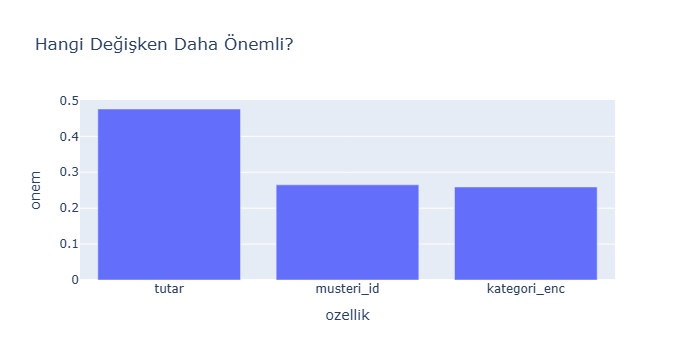

In [5]:
# Özellik önemi
onem = pd.DataFrame({
    'ozellik': X.columns,
    'onem':    model.feature_importances_
}).sort_values('onem', ascending=False)

print(onem)

# Grafik
import plotly.express as px
fig = px.bar(onem, x='ozellik', y='onem',
             title='Hangi Değişken Daha Önemli?')
fig.show()

In [6]:
# Veriyi yükle
fraud_df = pd.read_csv('creditcard.csv')

print("Satır sayısı:", len(fraud_df))
print("Sütun sayısı:", len(fraud_df.columns))
print("\nFraud dağılımı:")
print(fraud_df['Class'].value_counts())


Satır sayısı: 284807
Sütun sayısı: 31

Fraud dağılımı:
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Girdi ve çıktı
X = fraud_df.drop('Class', axis=1)
y = fraud_df['Class']

# Böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y  # fraud oranını korur
)

print("Eğitim seti:", len(X_train))
print("Test seti:  ", len(X_test))
print("\nTest setinde fraud sayısı:", y_test.sum())

Eğitim seti: 227845
Test seti:   56962

Test setinde fraud sayısı: 98


In [9]:
# Modeli kur ve eğit
model_fraud = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1  # tüm CPU çekirdeklerini kullan
)

print("Model eğitiliyor...")
model_fraud.fit(X_train, y_train)
print("Tamamlandı!")

# Tahmin et
y_pred = model_fraud.predict(X_test)

# Değerlendir
print("\nSonuçlar:")
print(classification_report(y_test, y_pred))

Model eğitiliyor...
Tamamlandı!

Sonuçlar:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



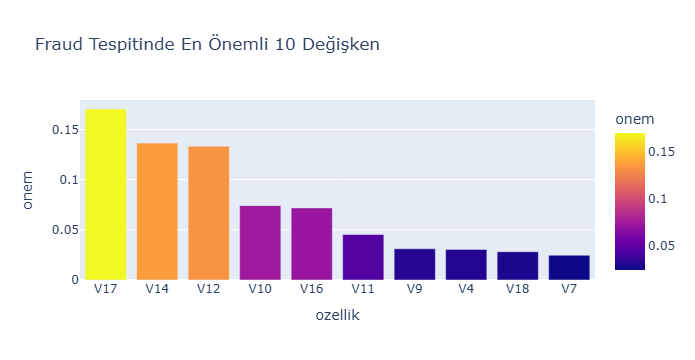

In [10]:
# Özellik önemi
onem_fraud = pd.DataFrame({
    'ozellik': X.columns,
    'onem':    model_fraud.feature_importances_
}).sort_values('onem', ascending=False).head(10)

fig = px.bar(
    onem_fraud,
    x     = 'ozellik',
    y     = 'onem',
    title = 'Fraud Tespitinde En Önemli 10 Değişken',
    color = 'onem'
)
fig.show()


## Gün 3 — Regresyon: Tutar Tahmini

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Kendi verimizi kullanalım
df2 = pd.read_csv('islemler.csv')

print(df2.head())
print("\nSütunlar:", df2.columns.tolist())

   islem_id  musteri_id    tutar   kategori      durum
0         1           1   1500.0  Alışveriş     onaylı
1         2           2    320.0     Fatura     onaylı
2         3           3   8900.0   Transfer  beklemede
3         4           1    450.0     Fatura     onaylı
4         5           4  12000.0   Transfer      iptal

Sütunlar: ['islem_id', 'musteri_id', 'tutar', 'kategori', 'durum']


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2['kategori_enc'] = le.fit_transform(df2['kategori'])
df2['durum_enc']    = le.fit_transform(df2['durum'])

# Girdi ve çıktı
X = df2[['musteri_id', 'kategori_enc', 'durum_enc']]
y = df2['tutar']

# Böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print("Eğitim:", len(X_train), "satır")
print("Test:  ", len(X_test), "satır")


Eğitim: 8 satır
Test:   2 satır


=== Linear Regression ===
MAE: 3297.36
R2:  -3.91

=== Random Forest ===
MAE: 2200.88
R2:  -3.3

Tahmin vs Gerçek:
   Gerçek  LR Tahmin  RF Tahmin
0  3300.0     6789.0     7672.0
1   320.0     3426.0      350.0


## Gün 5 — SHAP ile Model Açıklama

In [23]:
import shap

# SHAP açıklayıcı oluştur
explainer = shap.TreeExplainer(model_fraud)

# Test setinin ilk 100 satırı için SHAP değerleri hesapla
# (Tüm test seti çok uzun sürer)
X_sample = X_test_f.iloc[:100]
shap_values = explainer.shap_values(X_sample)

print("SHAP değerleri hesaplandı!")
print("Şekil:", shap_values.shape)

SHAP değerleri hesaplandı!
Şekil: (100, 30, 2)


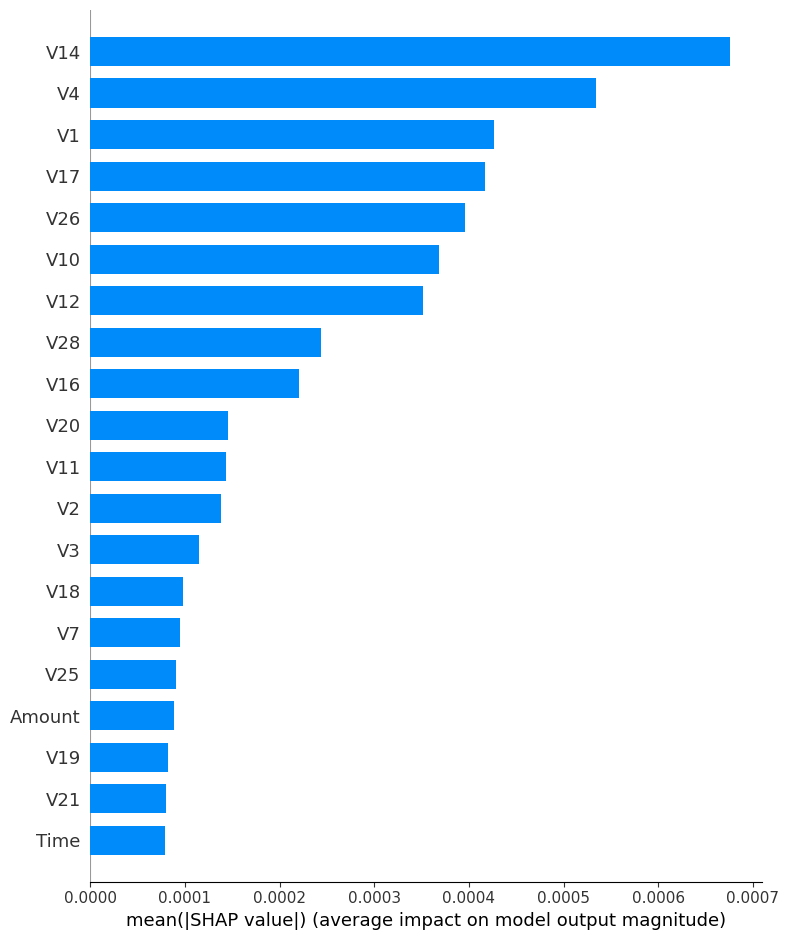

In [24]:
# Fraud sınıfı için SHAP değerleri (index 1)
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type = "bar",
    show      = True
)

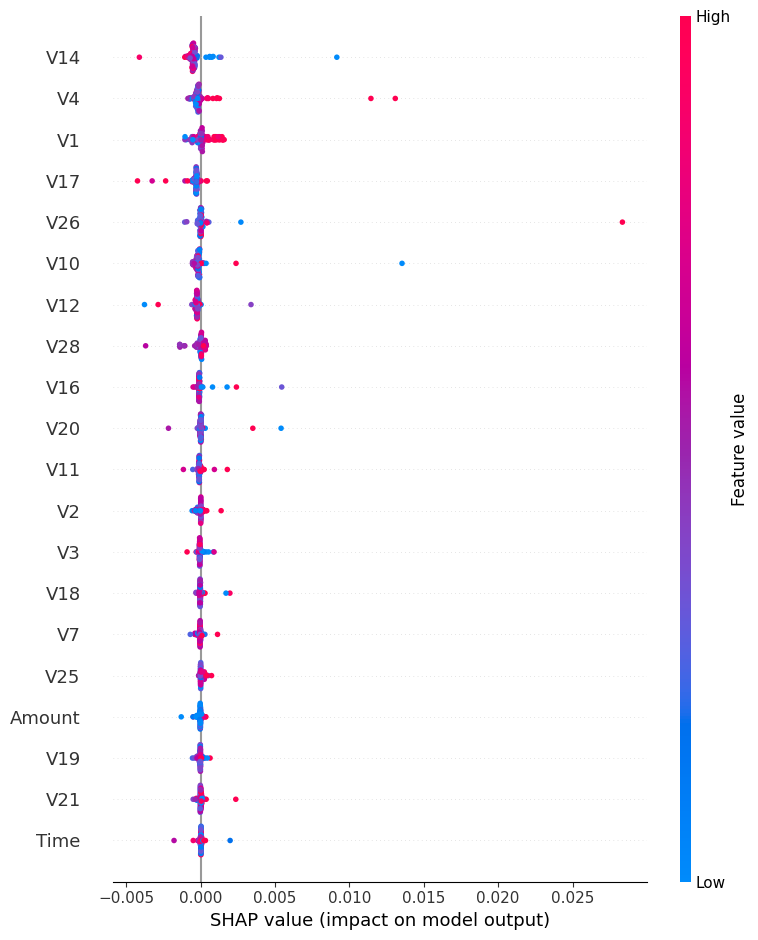

In [25]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    show = True
)

Fraud sayısı: 98


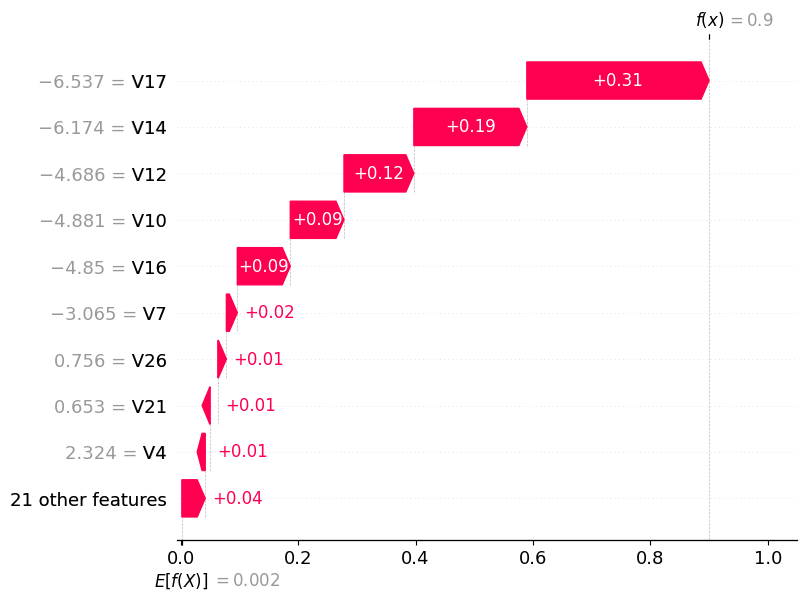

In [29]:
# Test setinden sadece fraud olanları al
fraud_rows = X_test_f[y_test_f == 1].iloc[:100]
shap_values_fraud = explainer.shap_values(fraud_rows)

print("Fraud sayısı:", len(fraud_rows))

# İlk fraud işlemini göster
shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values_fraud[0, :, 1],
        base_values   = explainer.expected_value[1],
        data          = fraud_rows.iloc[0],
        feature_names = fraud_rows.columns.tolist()
    )
)